# **Final Exam**
### Technologies for Big Data with Python3

### **NOTICE**
This notebook is composed by a set of short exercises and questions spanning through the content of the course (up until the `timeseries` topic, excluded).
It is divided into three parts:


1.   Basic Python3
2.   Spark RDD and Dataframe 
3.   Machine Learning

For each part, a set of resources is given to help you fulfilling the tasks.

**IMPORTANT** Rename the notebook with your surname, download it and send it to `marco.milanesio@univ-cotedazur.fr`.


In [0]:
# USUAL PREAMBLE: RUN THIS CELL
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
!update-alternatives --set java /usr/lib/jvm/java-8-openjdk-amd64/jre/bin/java
!java -version
!pip install pyspark

openjdk version "1.8.0_222"
OpenJDK Runtime Environment (build 1.8.0_222-8u222-b10-1ubuntu1~18.04.1-b10)
OpenJDK 64-Bit Server VM (build 25.222-b10, mixed mode)


# PART 1: Python3, numpy and pandas

*   [Standard library](https://docs.python.org/3.6/library/)
*   [numpy](https://docs.scipy.org/doc/numpy/reference/)
*   [pandas](https://pandas.pydata.org/pandas-docs/stable/)

## 1.1. 
Write a function `is_leap(year)` that check if a given year is leap or not. ([info](https://en.wikipedia.org/wiki/Leap_year))

In [0]:
def is_leap(year):
  """
  Check if 'year` is leap or not
  @param year: integer
  @return boolean
  """
  # write here your code
  

In [0]:
# TESTING CELL: DO NOT MODIFY
# run this cell to check if your code works properly: if so, no output will show up
assert is_leap(1980)
assert not is_leap(1977)
assert is_leap(2000)
assert not is_leap(2001)

## 1.2. 
Write a function `can_form_valid_triangle(list_of_lengths)` that checks if a given set of `lengths` can form a valid triangle and of which type (equilateral, isosceles, scalene).

*hint*: all permutations of the three lengths (`n = 3; lengths = [a,b,c]`) must satisfy the "triangle inequality" (e.g., `a < b + c`)


In [0]:
def can_form_valid_triangle(list_of_lengths):
  """
  Inspect a list of lengths to check if it's a valid triangle or not
  @param list_of_lengths: a list of integers
  @return Type of triangle (if it's a valid triangle) or False
  """
  pass


In [0]:
# TESTING CELL: DO NOT MODIFY
# run this cell to check if your code works properly: if so, no output will show up
assert can_form_valid_triangle([3,4,5]) == 'scalene'
assert not can_form_valid_triangle([1,3,4])
assert not can_form_valid_triangle([1,3,10])
assert can_form_valid_triangle([7,10,5])
assert can_form_valid_triangle([3,3,3]) == 'equilateral'
assert can_form_valid_triangle([6,6,3]) == 'isosceles'

## 1.3. 
Given the `numpy.array` `z` negate all elements `x` such that `3 < x <= 8`

*Note*: Boolean Series are combined using the `bitwise`, rather than the traditional boolean operators. For example, when performing logical and, use `&` instead of `and`.

In [0]:
import numpy as np
z = np.arange(11)
# write here your code



In [0]:
# TESTING CELL: DO NOT MODIFY
# run this cell to check if your code works properly: if so, no output will show up
assert np.sum(z) == -5
assert z[5] == -5

## 1.4.
Given the following `pandas` `Dataframe`:

In [0]:
import pandas as pd
city_names = pd.Series(['San Francisco', 'San Jose', 'Sacramento'])
population = pd.Series([852469, 1015785, 485199])
cities = pd.DataFrame({'City name': city_names, 'Population': population})

cities['Area square miles'] = pd.Series([46.87, 176.53, 97.92])
cities['Population density'] = cities['Population'] / cities['Area square miles']
cities

,City name,Population,Area square miles,Population density
0,San Francisco,852469,46.87,18187.945381
1,San Jose,1015785,176.53,5754.177760
2,Sacramento,485199,97.92,4955.055147



Modify the `cities` table by adding a new `boolean` column that is `True` if and only if both of the following are True:

*    The city is named after a saint.
*    The city has an area greater than 50 square miles.

*Hint*: "San" in Spanish means "saint."

In [0]:
# write here your code
cities['Is wide and has saint name'] = ...

In [0]:
# TESTING CELL: DO NOT MODIFY
# run this cell to check if your code works properly: if so, no output will show up
assert all(cities['Is wide and has saint name'] == pd.Series([False, True, False]))

# PART 2: Pyspark

*  [Pyspark API](https://spark.apache.org/docs/latest/api/python/index.html)
*  [Learning Apache Spark](https://runawayhorse001.github.io/LearningApacheSpark/index.html)


In [0]:
# RUN THIS CELL BEFORE PROCEEDING
# pyspark-related imports
from pyspark.sql import SparkSession, SQLContext


## 2.1

Create a spark session object `spark` named `'exam'`, extract the spark context.


In [0]:
# write here your code
spark = ...  # the base spark session for this exam
sc = ...  # the spark context attached to the session

### 2.2
Using the RDD api, 

*   parallelize the given list into a RDD called `rdd`
*   sum all odd elements

In [0]:
# RUN THIS CELL
np.random.seed(1234) # for reproducibility
data = np.random.randint(100, size=25)


In [0]:
# write here your code
rdd = 
result = 

In [0]:
# TESTING CELL: DO NOT MODIFY
# run this cell to check if your code works properly: if so, no output will show up
assert result == 539

# PART 3: Machine Learning


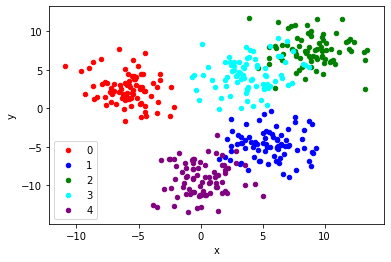

In [0]:
# Execute this cell to generate the data needed.
from sklearn.datasets.samples_generator import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=400, centers=5, n_features=4, cluster_std=2, random_state=1234)
df = pd.DataFrame(dict(x=X[:,0], y=X[:,1], label=y))
colors = {0:'red', 1:'blue', 2:'green', 3:'cyan', 4:'purple'}
fig, ax = plt.subplots()
grouped = df.groupby('label')
for key, group in grouped:
    group.plot(ax=ax, kind='scatter', x='x', y='y', label=key, color=colors[key])
plt.show()

## 3.1 
Create a `Spark` Dataframe using the `df` dataframe defined in previous cell.

*hint* you'll need a sqlcontext to to this...

In [0]:
# write here your code



## 3.2 
Create a KMeans model on `sdf`, with `k = 4`. 
Show the population in each cluster and the total cost on the final clustering.

*hint*: being the coordinates quite different between each other it will be better to scale them using a `StandardScaler`.

In [0]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler

# write here your code


Is it good or bad?
Try with different number of `k` to check if there is a better clustering.

## 3.3
